# Function 7

## Check sys.path

In [1]:
# Checking that PYTHONPATH has been set to include local modules and included with sys.path

import os
try:
    print(f'PYTHONPATH:\n{os.environ['PYTHONPATH'].split(os.pathsep)}')
except KeyError:
    pass

import sys
print(f'\nsys.path:\n{'\n'.join(sys.path)}')

PYTHONPATH:
['C:\\Users\\antho\\Git\\LearningPython\\']

sys.path:
C:\Users\antho\Git\LearningPython
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\python314.zip
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\DLLs
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages


## Pandas dataframe display options

In [2]:
import pandas as pd

# Prevents dataframe rows being "split" and displayed across multiple lines
pd.set_option('display.expand_frame_repr', False)

# Show all columns
pd.set_option('display.max_columns', None)

## Imports

In [3]:
# Load extension to auto re-import script changes without having to restart Python kernel 
%load_ext autoreload

# Set autoreload = 2 (reloads everything before every cell execution)
%autoreload 2

# Import scripts common across all BBOFunction notebooks. '%run' ensures variables/imports become part of this notebook's namespace
%run imports.py

## Function 7 Description

*You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function.*

*Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.*

## BBO parameters

In [4]:
func_no = 7
sub_week = 13

display(Markdown(f'**function number:** {func_no}'))
display(Markdown(f'**submission week:** {sub_week}'))

**function number:** 7

**submission week:** 13

## Load data

In [5]:
initial_len, y_pred, x_dim, x_col_names, df = data_helper.get_data(func_no, sub_week)

initial data points: 30
initial max: 1.3649683044991994
submission data points: 12
current max: 2.8146793987262457 (from submission week: 12)
x_dim: 6


<br>**DataFrame:**

          x1        x2        x3        x4        x5        x6         y
41  0.013029  0.175723  0.543395  0.261872  0.290036  0.688024  2.814679
39  0.000000  0.195720  0.501370  0.265921  0.296263  0.688903  2.785952
40  0.006534  0.174659  0.516406  0.252959  0.275039  0.687683  2.766417
38  0.000000  0.202494  0.584643  0.270358  0.314935  0.681786  2.713704
37  0.000000  0.048920  0.514342  0.328847  0.285368  0.721254  2.548091
36  0.022436  0.347704  0.439457  0.209838  0.301694  0.634647  2.442600
35  0.023822  0.317349  0.441843  0.172666  0.319320  0.660437  2.421789
32  0.034257  0.332685  0.394239  0.188044  0.317655  0.658716  2.415937
33  0.000000  0.282874  0.429983  0.148434  0.310556  0.637554  2.290234
30  0.019989  0.344445  0.338456  0.142150  0.354157  0.752105  1.847594
34  0.000000  0.371461  0.067262  0.222869  0.297620  0.627922  1.759457
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
31  0.000000  0.226553  0.350445  0.045287  0.32593

### Manually omit columns or other data amends (if desired)

## Distance between x points

In [6]:
dists, min_dist, max_dist = distance_helper.distances_between_points(x = df[x_col_names].values)

#display(Markdown('**Distances between x points:**'))
#for row in dists:
#    print(f'{row}')

display(Markdown(f'**min_dist:** {min_dist}'))
display(Markdown(f'**max_dist:** {max_dist}')) 

**min_dist:** 0.032805

**max_dist:** 1.573748

## Tune Gaussian Process surrogate model

### Setup hyperparameters to trial (kernels, x_tansform and y_transform)

In [7]:
kernels = gaussian_process_helper.get_kernels(x_dim)

print(kernels.keys())

dict_keys(['Matern 2.5', 'Matern 1.5', 'Matern 0.5', 'RBF', 'Rational Quad', 'Periodic', 'Locally Periodic', 'Linear + RBF', 'Matern 2.5 + WhiteK', 'Matern 1.5 + WhiteK', 'Matern 0.5 + WhiteK', 'RBF + WhiteK', 'Rational Quad + WhiteK', 'Periodic + WhiteK', 'Locally Periodic + WhiteK', 'Linear + RBF + WhiteK', 'Local Sens + Mat 2.5 + WhiteK', 'Ridge + RQ + WhiteK', 'Local Sens + Ridge + Mat 2.5 + WhiteK'])


In [8]:
y_transforms = transform_helper.get_y_transformers()

print(y_transforms.keys())

dict_keys(['none', 'scaled', 'power', 'pow-scaled', 'logshift', 'logshift-scaled'])


In [9]:
x_transforms = transform_helper.get_x_transformers()

print(x_transforms.keys())

dict_keys(['none', 'scaled'])


### Manually override hyperparameter options (if desired)

### Perform the hyperparameter tuning

In [10]:
df_tuning_results, model_dict = gaussian_process_helper.tune_gaussian_process_surrogate(
    df = df,
    x_col_names = x_col_names,
    kernels = kernels,
    y_transforms = y_transforms,
    x_transforms = x_transforms,
)


Matern 2.5, x:none, y:none...
         y_t    mean_t   resid_t     std_t    y_pred
41  2.814679  2.796890 -0.017789  0.016192  2.796890
39  2.785952  2.773665 -0.012286  0.024742  2.773665
40  2.766417  2.790959  0.024542  0.027043  2.790959
38  2.713704  2.755863  0.042159  0.039797  2.755863
37  2.548091  2.662833  0.114742  0.104819  2.662833
36  2.442600  2.470097  0.027497  0.054282  2.470097
35  2.421789  2.425065  0.003276  0.017253  2.425065
32  2.415937  2.409546 -0.006392  0.019077  2.409546
33  2.290234  2.284257 -0.005977  0.048208  2.284257
30  1.847594  1.935225  0.087630  0.127720  1.935225
34  1.759457  1.859728  0.100271  0.145656  1.859728
6   1.364968  1.229588 -0.135380  0.236793  1.229588
31  0.986270  0.951634 -0.034637  0.326730  0.951634
24  0.675142  0.836062  0.160920  0.408515  0.836062
14  0.611526  0.323595 -0.287930  0.428460  0.323595
0   0.604433  0.493821 -0.110612  0.319982  0.493821
1   0.562753  0.084427 -0.478326  0.420822  0.084427
25  0.516457  0

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
41  1.958432  1.927859 -0.030573  0.022222  2.783518
39  1.930246  1.949207  0.018960  0.049687  2.805276
40  1.911080  1.932979  0.021899  0.026844  2.788737
38  1.859362  1.909974  0.050613  0.053717  2.765290
37  1.696873  1.681752 -0.015121  0.197834  2.532679
36  1.593372  1.618912  0.025540  0.057541  2.468631
35  1.572953  1.557156 -0.015797  0.039250  2.405688
32  1.567212  1.525262 -0.041950  0.043703  2.373181
33  1.443880  1.538869  0.094988  0.077809  2.387049
30  1.009590  1.054515  0.044924  0.094417  1.893383
34  0.923115  0.422793 -0.500323  0.365188  1.249515
6   0.536068  0.680424  0.144356  0.246753  1.512099
31  0.164514  0.344917  0.180403  0.282777  1.170142
24 -0.140746 -0.625000 -0.484255  0.462946  0.181577
14 -0.203162  0.400818  0.603980  0.460032  1.227118
0  -0.210121 -0.392591 -0.182470  0.468654  0.418454
1  -0.251014 -0.783484 -0.532470  0.516609  0.020046
25 -0.296437 -0.300314 -0.003877  0.472539  0.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
41  0.628401  0.628028 -0.000374  0.001637  2.806763
39  0.627103  0.631759  0.004656  0.004063  2.894034
40  0.626206  0.625627 -0.000580  0.002100  2.754539
38  0.623733  0.623686 -0.000048  0.003821  2.714713
37  0.615405  0.602376 -0.013029  0.025749  2.386055
36  0.609613  0.608940 -0.000672  0.004628  2.433028
35  0.608421  0.607618 -0.000804  0.002952  2.408795
32  0.608083  0.607877 -0.000206  0.003101  2.413361
33  0.600482  0.606409  0.005927  0.007678  2.393133
30  0.567407  0.570022  0.002615  0.007451  1.880592
34  0.559336  0.514460 -0.044875  0.045869  1.426793
6   0.514497  0.494888 -0.019609  0.023275  1.241981
31  0.451463  0.457803  0.006340  0.033728  1.035544
24  0.374214  0.237418 -0.136796  0.083028  0.353724
14  0.354102  0.450941  0.096839  0.066855  1.056478
0   0.351745  0.380844  0.029099  0.092173  0.780260
1   0.337391  0.151113 -0.186277  0.109874  0.212000
25  0.320369  0.147886 -0.172483  0.093887  0.

...

         y_t    mean_t   resid_t     std_t    y_pred
41  2.814679  2.797722 -0.016957  0.016879  2.797722
39  2.785952  2.780515 -0.005436  0.024217  2.780515
40  2.766417  2.791028  0.024612  0.030917  2.791028
38  2.713704  2.755193  0.041490  0.046205  2.755193
37  2.548091  2.644190  0.096099  0.107962  2.644190
36  2.442600  2.465414  0.022814  0.057935  2.465414
35  2.421789  2.431373  0.009584  0.019151  2.431373
32  2.415937  2.403750 -0.012187  0.020943  2.403750
33  2.290234  2.275742 -0.014492  0.050180  2.275742
30  1.847594  1.891723  0.044128  0.154037  1.891723
34  1.759457  1.909324  0.149867  0.159216  1.909324
6   1.364968  1.287343 -0.077625  0.254292  1.287343
31  0.986270  1.136240  0.149969  0.375547  1.136240
24  0.675142  0.850119  0.174978  0.407689  0.850119
14  0.611526  0.647592  0.036067  0.443030  0.647592
0   0.604433  0.471915 -0.132517  0.326058  0.471915
1   0.562753 -0.000011 -0.562764  0.432692 -0.000011
25  0.516457  0.574468  0.058011  0.358369  0.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k1__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
41  1.958432  1.942053 -0.016379  0.016992  2.797985
39  1.930246  1.926196 -0.004050  0.024258  2.781824
40  1.911080  1.934053  0.022974  0.031314  2.789832
38  1.859362  1.898563  0.039201  0.046788  2.753659
37  1.696873  1.784200  0.087328  0.108563  2.637097
36  1.593372  1.612122  0.018750  0.058226  2.461711
35  1.572953  1.582760  0.009807  0.019348  2.431784
32  1.567212  1.554544 -0.012668  0.021119  2.403025
33  1.443880  1.431931 -0.011949  0.050410  2.278056
30  1.009590  1.041603  0.032012  0.155660  1.880222
34  0.923115  1.080037  0.156922  0.159168  1.919396
6   0.536068  0.480384 -0.055685  0.252749  1.308213
31  0.164514  0.382228  0.217714  0.371111  1.208170
24 -0.140746  0.027173  0.167918  0.399663  0.846288
14 -0.203162 -0.113262  0.089900  0.432290  0.703154
0  -0.210121 -0.330763 -0.120643  0.320503  0.481471
1  -0.251014 -0.788272 -0.537257  0.422234  0.015166
25 -0.296437 -0.201585  0.094852  0.351303  0.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t    y_pred
41  0.628401  0.625803 -0.002598  0.002707  2.758759
39  0.627103  0.629846  0.002743  0.004229  2.850026
40  0.626206  0.628382  0.002176  0.004447  2.817246
38  0.623733  0.629454  0.005721  0.006706  2.845334
37  0.615405  0.607462 -0.007943  0.027149  2.486415
36  0.609613  0.606560 -0.003053  0.009244  2.398354
35  0.608421  0.609511  0.001090  0.002986  2.441733
32  0.608083  0.605858 -0.002225  0.003230  2.379015
33  0.600482  0.603137  0.002655  0.008829  2.340189
30  0.567407  0.569325  0.001919  0.016024  1.883566
34  0.559336  0.577793  0.018458  0.021837  2.001406
6   0.514497  0.488672 -0.025825  0.033434  1.214447
31  0.451463  0.481390  0.029928  0.059642  1.224092
24  0.374214  0.343149 -0.031065  0.059747  0.602285
14  0.354102  0.356628  0.002525  0.072765  0.658248
0   0.351745  0.310679 -0.041066  0.059451  0.509914
1   0.337391  0.197179 -0.140211  0.076385  0.272895
25  0.320369  0.279593 -0.040775  0.070837  0.

## Analytical Leave-One-Out Cross-Validation (LOOCV) Model Results

In [11]:
# Sort df_tuning_results:
# Mean-Square_Error (MSE) - The "best" kernel is the one with the lowest MSE    
# Log-Marginal Likelihood (LML) - The "best" kernel is the one with the highest LML
sort_columns = [Y_SMSE_TOP, Y_SMSE, Z_SMSE, LML]
sort_orders  = [      True,   True,   True, False]

#sort_columns = [Y_SMSE, Z_SMSE, LML]
#sort_orders  = [  True,   True, False]

df_tuning_results_sorted = df_tuning_results.sort_values(by=sort_columns, ascending=sort_orders)

# Format numeric display columns
display_cols = [MODEL, Z_SMSE, Y_SMSE, Y_SMSE_TOP, LML, KERNEL_PARAMS ]
for col in display_cols:
    df_tuning_results_sorted[col] = df_tuning_results_sorted[col].apply(format_sig_figs)

print(df_tuning_results_sorted[display_cols].to_string(index=False))

                                                             Model    Z_SMSE     Y_SMSE  Y_SMSE_TOP       LML                                                                                                                                                                                               Kernel_Params
                       Linear + RBF + WhiteK, x:none, y:pow-scaled 0.0606043 0.00988154 0.000372661  0.409806                                                                                       DotProduct(sigma_0=9.54e-05) + 0.547**2 * RBF(len_scale=[1.16, 10, 0.978, 0.373, 0.221, 0.241]) + WhiteK(noise=1e-07)
                 Local Sens + Mat 2.5 + WhiteK, x:scaled, y:scaled 0.0247615  0.0247615 0.000509188  -7.85356                                            0.451**2 * Matern(len_scale=[2.5, 10, 3.66, 1.26, 0.665, 0.948], nu=1.5) + 0.456**2 * Matern(len_scale=[4.44, 10, 10, 10, 10, 10], nu=2.5) + WhiteK(noise=1e-07)
                   Local Sens + Mat 2.5 + WhiteK, x:none, 

## Save LOOCV Results to csv

In [12]:
folder_path = 'results'
file_name = f'BBO_Func{func_no}_Week{sub_week}_LOOCV_Results.csv'

# Create the folder if it doesn't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

# Now save the file
df_tuning_results_sorted.to_csv(f'{folder_path}/{file_name}', index=False)

## LOOCV Detailed Results for best model (Optionally override auto selected best model)

In [13]:
best_model_name = df_tuning_results_sorted[MODEL].iloc[0]

# Manually overriding best_model (optional)
override_model_name = None

if not override_model_name is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding best model from "{best_model_name}" to "{override_model_name}"**</span>'))
    best_model_name = override_model_name
    
best_model_dict = model_dict[best_model_name]
best_model = best_model_dict[MODEL]
x_transform = best_model_dict[X_TRANSFORM]
y_transform = best_model_dict[Y_TRANSFORM]

display(Markdown(f'<br>**Best model:**<br>{best_model_name}'))

params_str = extract_optimised_kernel_params_str(best_model)
display(Markdown(f'**Optimised parameters:**'))
print(params_str) # Own print() since it contains **

best_loocv_results = best_model_dict[LOOCV]

# Add the best model LOOCV results to df for easier display 
for label, content in best_loocv_results.items():
    df[label] = content

display(Markdown(f'<br>**LOOCV Predictions using best model:**<br>'))
print(df)

<br>**Best model:**<br>Linear + RBF + WhiteK, x:none, y:pow-scaled

**Optimised parameters:**

DotProduct(sigma_0=9.54e-05) + 0.547**2 * RBF(len_scale=[1.16, 10, 0.978, 0.373, 0.221, 0.241]) + WhiteK(noise=1e-07)


<br>**LOOCV Predictions using best model:**<br>

          x1        x2        x3        x4        x5        x6         y       y_t    mean_t   resid_t     std_t    y_pred
41  0.013029  0.175723  0.543395  0.261872  0.290036  0.688024  2.814679  1.500302  1.497491 -0.002811  0.003347  2.799687
39  0.000000  0.195720  0.501370  0.265921  0.296263  0.688903  2.785952  1.494927  1.494257 -0.000670  0.006159  2.782729
40  0.006534  0.174659  0.516406  0.252959  0.275039  0.687683  2.766417  1.491218  1.494553  0.003335  0.004704  2.784158
38  0.000000  0.202494  0.584643  0.270358  0.314935  0.681786  2.713704  1.480984  1.488092  0.007109  0.007645  2.750619
37  0.000000  0.048920  0.514342  0.328847  0.285368  0.721254  2.548091  1.446520  1.449145  0.002625  0.019625  2.562756
36  0.022436  0.347704  0.439457  0.209838  0.301694  0.634647  2.442600  1.422552  1.416574 -0.005978  0.014168  2.418599
35  0.023822  0.317349  0.441843  0.172666  0.319320  0.660437  2.421789  1.417620  1.416657 -0.000963  0.004692  2.417888
32  0.034257  0.

## y and y_t (y transformed) plots

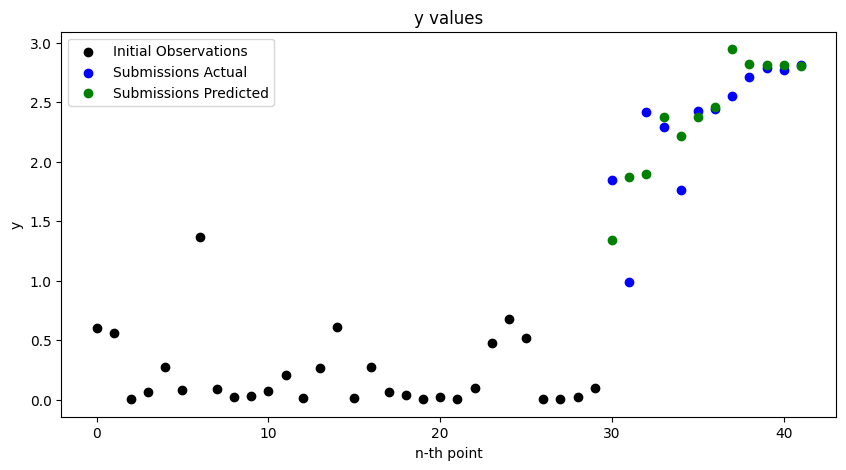

In [14]:
plot_helper.sequence_plot(df["y"], initial_len, y_pred)

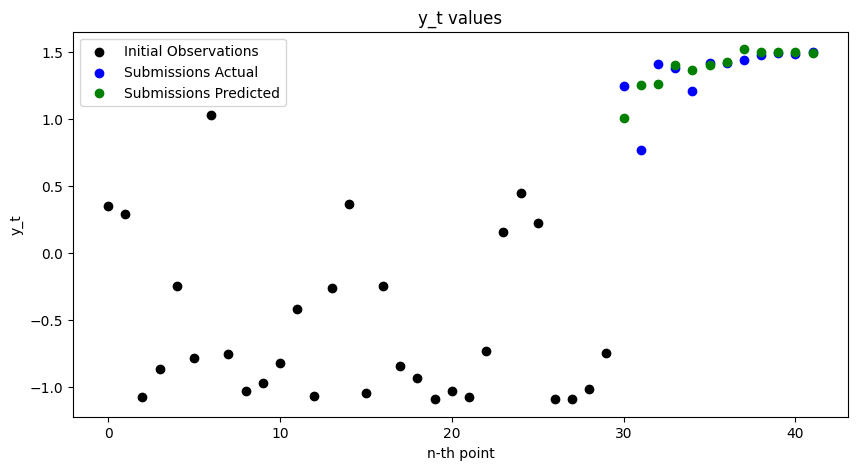

In [15]:
y_t_pred = y_transform.transform(y_pred)
plot_helper.sequence_plot(df["y_t"], initial_len, y_t_pred)

## Determine next evaluation point

### Create grid

In [16]:
x_grid = grid_helper.hypercube_grid([5, 5, 5, 5, 5, 5], x_col_names)

#print(x_grid[0:5])

len(x_grid): 46656


### Maximise UCB and EI acquisition functions

In [17]:
# Small xi (0.0 – 0.01) - Exploitation dominant
# Moderate xi (0.01 – 0.1) - Balanced
# Large xi (0.5+) Strong exploration
ei_xis = [ 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0 ]
ucb_betas = [ 10, 5, 2, 1, 0.5, 0.1, 0.05, 0.01, 0 ]
acq_fns = acquisition_fns_helper.get_acq_fns(df, y_transform, ei_xis = ei_xis, ucb_betas = ucb_betas)

# Bespoke bounds to force suggested next x near current x_best:
override_bounds = None # E.g. [(0.5, 0.9), (0.1, 0.4), ...]

if not override_bounds is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding acquisition function optimisation bounds to "{override_bounds}"**</span>'))
    
df_acq_results = acquisition_fns_helper.determine_next_eval_points(df, best_model, x_grid, x_col_names, x_transform, y_transform, x_dim, acq_fns, bounds = override_bounds, opt_trials=1000)

EI trans space (xi=2)...
Acq Fn([0.       0.       0.999999 0.999999 0.       0.      ]) = 4.793802618995921e-10, distance: 0.9122694345929786, y_t_best: [-0.11401077], y_best: [0.43815582]
EI trans space (xi=1)...
Acq Fn([0.       0.       0.999999 0.6      0.       0.999999]) = 3.967608009441525e-06, distance: 0.5566688260401556, y_t_best: [0.4124399], y_best: [0.85228858]
EI trans space (xi=0.5)...
Acq Fn([0.         0.         0.999999   0.67561248 0.         0.999999  ]) = 0.0001878637647824144, distance: 0.5294991964770958, y_t_best: [0.44869161], y_best: [0.89251268]
EI trans space (xi=0.1)...
Acq Fn([0.         0.         0.999999   0.70841226 0.         0.999999  ]) = 0.002286978952525982, distance: 0.5206955712575572, y_t_best: [0.4610205], y_best: [0.90155768]
EI trans space (xi=0.05)...
Acq Fn([0.         0.         0.999999   0.71246249 0.         0.999999  ]) = 0.0030173327953068457, distance: 0.5197417243881611, y_t_best: [0.46235526], y_best: [0.90186173]
EI trans space

### Display the acquisition function results

In [18]:
display(Markdown(f'<br>**EXISTING BEST:**'))
print(f'Actual y: {df['y'].iloc[0]}\nActual y_t: {df['y_t'].iloc[0]}\nx: {df[x_col_names].iloc[0].values}')

x_t = x_transform.transform(df[x_col_names].iloc[0].values.reshape(-1,x_dim))
y_t_mean, y_t_std = best_model.predict(np.atleast_2d(x_t), return_std=True)
y_mean, y_std = y_transform.inverse_transform_dist(y_t_mean, y_t_std)

display(Markdown(f'<br>**Model\'s [{best_model_name}] prediction at x corresponding to the best y.**'))
print(f'NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.')
print(f'y_t_mean: {y_t_mean}, y_t_std: {y_t_std}\ny_mean: {y_mean}\n')

# Add a y_mean ranking
df_acq_results['y_mean rank'] = df_acq_results['y_mean'].rank(ascending=False, method='min').astype(int)

display(Markdown(f'<br>**FUNCTION {func_no} SUBMISSION WEEK {sub_week}:**<br>'))
print(df_acq_results.to_string(index=False))

<br>**EXISTING BEST:**

Actual y: 2.8146793987262457
Actual y_t: 1.5003021014685674
x: [0.013029 0.175723 0.543395 0.261872 0.290036 0.688024]


<br>**Model's [Linear + RBF + WhiteK, x:none, y:pow-scaled] prediction at x corresponding to the best y.**

NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.
y_t_mean: [1.50027701], y_t_std: [0.00044621]
y_mean: [2.81454586]



<br>**FUNCTION 7 SUBMISSION WEEK 13:**<br>

                     acq_fn                  ['x1', 'x2', 'x3', 'x4', 'x5', 'x6']  distance  y_t_mean   y_mean  y_mean rank
      EI trans space (xi=2) 0.000000-0.000000-0.999999-0.999999-0.000000-0.000000  0.912269 -0.114011 0.438156           17
      EI trans space (xi=1) 0.000000-0.000000-0.999999-0.600000-0.000000-0.999999  0.556669  0.412440 0.852289           15
    EI trans space (xi=0.5) 0.000000-0.000000-0.999999-0.675612-0.000000-0.999999  0.529499  0.448692 0.892513           14
    EI trans space (xi=0.1) 0.000000-0.000000-0.999999-0.708412-0.000000-0.999999  0.520696  0.461021 0.901558           13
   EI trans space (xi=0.05) 0.000000-0.000000-0.999999-0.712462-0.000000-0.999999  0.519742  0.462355 0.901862           12
   EI trans space (xi=0.01) 0.000000-0.000000-0.533338-0.232880-0.299368-0.678777  0.118169  1.559683 3.179353            2
  EI trans space (xi=0.005) 0.000000-0.000000-0.534248-0.232895-0.299215-0.679126  0.118164  1.559697 3.179317            3
  EI tra

## Manually calculating the prediction at an x point (Helper method)